# Shor's Algorithm — Demo

Walks through `algorithms.shor` end to end: build the order-finding circuit
for a specific base, run it on `AerSimulator`, extract the order via
continued fractions, recover a factor, and finally run the whole pipeline
via `factor(15)`.

See [../math.md](../math.md) for the number theory and [../paper.md](../paper.md)
for the circuit derivation this notebook exercises.

In [1]:
# Make the repo importable regardless of the working directory this
# notebook is executed from (e.g. `jupyter execute` defaults to the
# notebook's own directory, not the repo root).
import sys
from pathlib import Path

repo_root = Path.cwd()
while not (repo_root / "pyproject.toml").exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root))

In [2]:
from algorithms.shor import visualization
from algorithms.shor.circuit import build_order_finding_circuit
from algorithms.shor.execution import AerExecutor
from algorithms.shor.implementation import factor, find_order, recover_factor

N, a = 15, 7
print(f"Factoring N={N} using base a={a} (gcd(a, N) == 1, so a is a valid base)")

Factoring N=15 using base a=7 (gcd(a, N) == 1, so a is a valid base)


## The order-finding circuit

`build_order_finding_circuit` puts the counting register in superposition,
applies controlled powers of the modular-multiplication oracle
(`PermutationMatrixOracle` by default — see RFC-0001), and finishes with the
from-scratch inverse QFT before measuring.

12 qubits: [QuantumRegister(8, 'count'), QuantumRegister(4, 'work')]


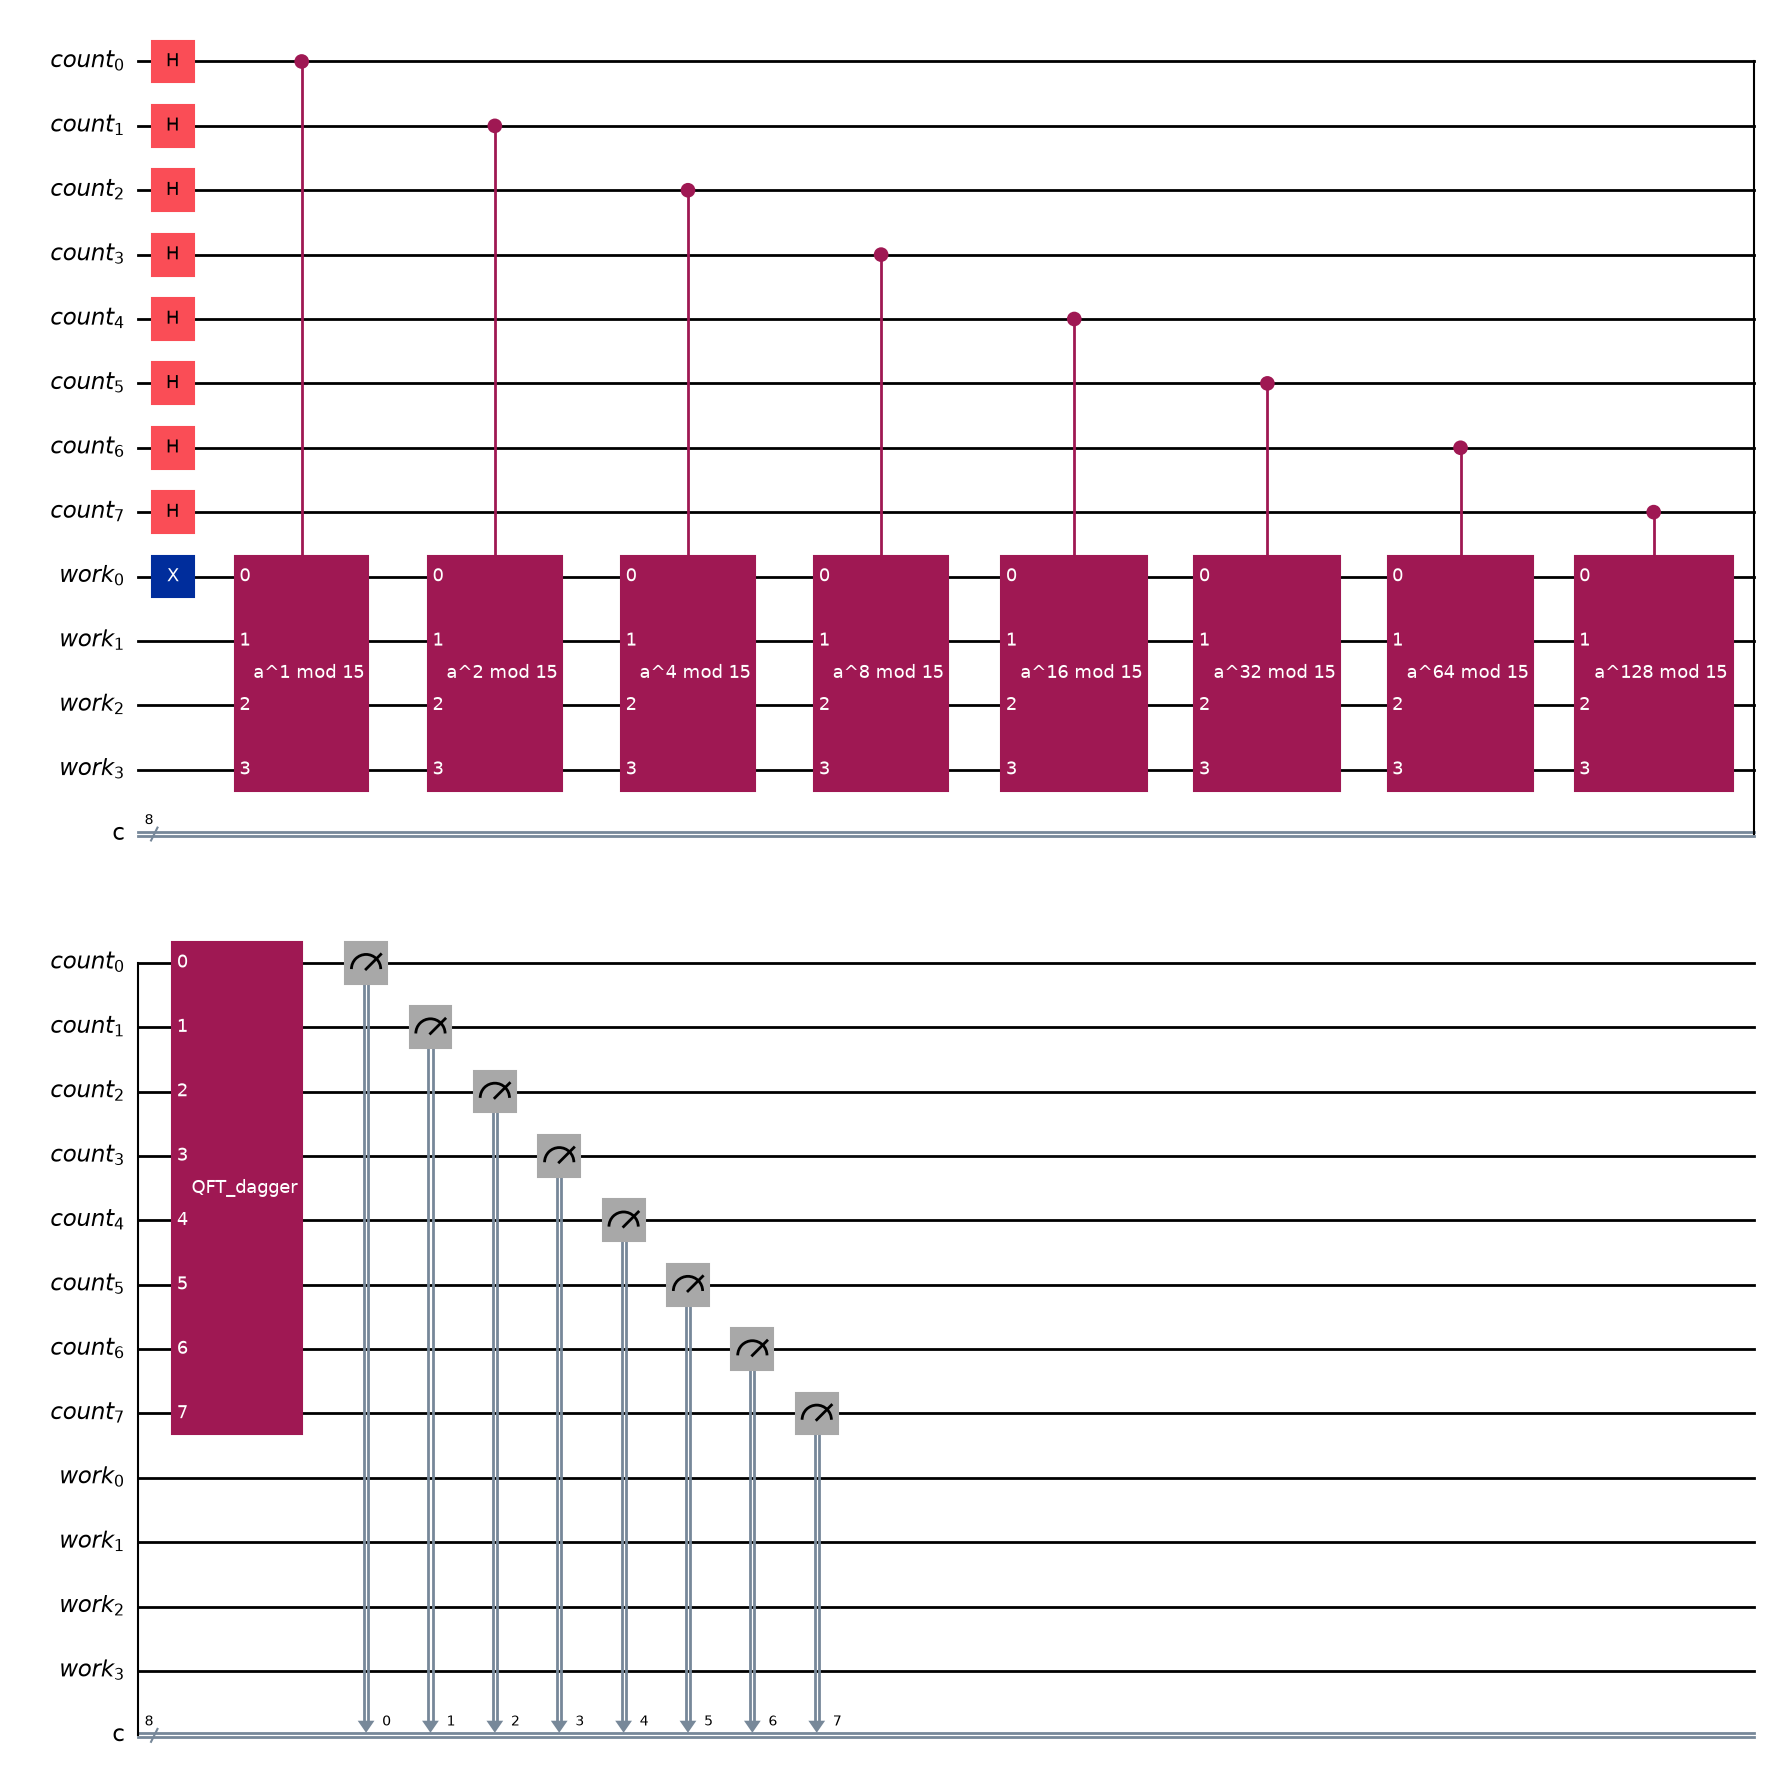

In [3]:
circuit = build_order_finding_circuit(N, a)
print(f"{circuit.num_qubits} qubits: {circuit.qregs}")
visualization.circuit_figure(circuit)

## Running it

1000 shots on `AerSimulator`, via the same `Executor` seam `find_order` uses
internally. The measured bitstrings cluster into 4 peaks — the phase
estimate `s/r` for each of `r=4`'s possible numerators `s = 0, 1, 2, 3`
(since the order of 7 mod 15 is 4).

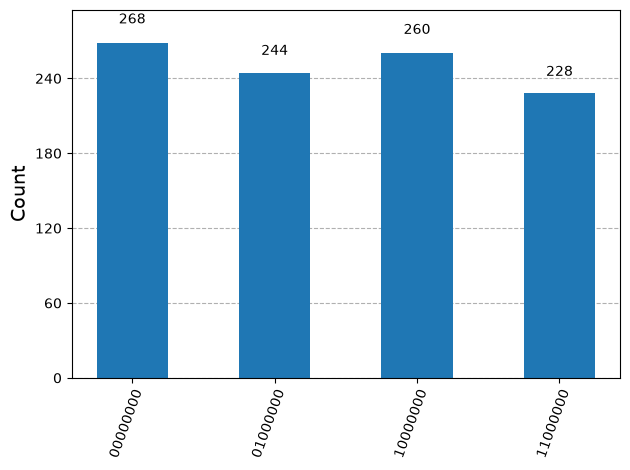

In [4]:
executor = AerExecutor()
counts = executor.run(circuit, shots=1000)
visualization.plot_measurement_histogram(counts)

## Order finding and factor recovery

`find_order` wraps the circuit-building and execution above, converts the
most-frequent measured bitstring to a phase, and extracts a candidate order
via continued fractions (`fractions.Fraction.limit_denominator`).

In [5]:
result = find_order(a, N)
print(result)

OrderFindingResult(success=False, order=None, measured_phase=0.5, measured_bitstring='10000000', continued_fraction=Fraction(1, 2), backend='aer_simulator', shots=1)


Order-finding is probabilistic (math.md's ~1/2 success argument) — if
`result.success` is `False` above, re-run the previous cell; a different
peak was measured. Given a successful order, `recover_factor` does the
classical gcd step:

In [6]:
if result.success:
    factors = recover_factor(N, a, result.order)
    print(f"order={result.order} -> factors={factors}")
else:
    print(
        "This attempt's measured phase didn't yield a usable order; "
        "see factor() below for the full retry loop."
    )

This attempt's measured phase didn't yield a usable order; see factor() below for the full retry loop.


## End to end: `factor(15)`

`factor` wraps `choose_base` / `find_order` / `recover_factor` in a retry
loop, so it succeeds reliably without manual intervention.

In [7]:
import random

factors = factor(15, rng=random.Random(0))
print(f"factor(15) = {factors}")
assert factors[0] * factors[1] == 15

factor(15) = (3, 5)


## Comparing oracles (RFC-0002)

`GateDecomposedOracle` computes the same operation from actual reversible
arithmetic gates rather than a classically-precomputed unitary — at a steep
qubit and gate-count cost. See [benchmarks/shor.md](../../../benchmarks/shor.md)
for the full timing comparison (simulating it is too slow to run routinely
in this notebook).

In [8]:
from qiskit import transpile

from algorithms.shor.oracles import GateDecomposedOracle

gd_circuit = build_order_finding_circuit(N, a, oracle_cls=GateDecomposedOracle)
gd_transpiled = transpile(gd_circuit, executor.backend)
default_transpiled = transpile(circuit, executor.backend)

print(f"PermutationMatrixOracle: {circuit.num_qubits} qubits, {default_transpiled.size()} gates")
print(f"GateDecomposedOracle:    {gd_circuit.num_qubits} qubits, {gd_transpiled.size()} gates")

PermutationMatrixOracle: 12 qubits, 1285 gates
GateDecomposedOracle:    19 qubits, 127039 gates
